# Commodity Clustering — Similar Pricing Behavior

**Goal:** group commodities by how they *behave*, not by raw price level, using:
- **Volatility features** (CV, avg daily min-max range) — available for every commodity
- **Seasonality features** (STL seasonal/trend strength, peak month) — only reliable for commodities with enough history
- **Shape-based clustering** — DTW distance between normalized month-of-year price profiles, so commodities with the same *seasonal curve shape* land together even if their volatility differs

**Tiering (from the EDA coverage report):** this dataset has commodities spanning the full 2013–2021 period alongside commodities only tracked from ~2019 onward. STL needs ~1.5+ years minimum to trust a yearly seasonal estimate, so:
- **Tier 1** (long history): full feature set → richer clustering
- **Tier 2** (short history): volatility-only features, included in the all-commodity volatility clustering but excluded from the seasonality-based clustering

This notebook produces **two feature-based clusterings** (volatility-only, all commodities / volatility+seasonality, Tier 1 only) **and one shape-based clustering** (DTW on seasonal profiles), so you can compare all three.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
%matplotlib inline


# ---- Project root: resolved relative to this notebook, independent of the machine/OS it runs on ----
def _find_project_root(marker=os.path.join("data", "raw", "kalimati_tarkari_dataset.csv")):
    path = os.getcwd()
    for _ in range(6):
        if os.path.exists(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            break
        path = parent
    raise FileNotFoundError(
        "Could not locate the project root (expected to find data/raw/kalimati_tarkari_dataset.csv "
        "within a few parent directories of the current working directory).")


PROJECT_ROOT = _find_project_root()

# ---- CONFIG ----
CSV_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "kalimati_tarkari_dataset.csv")          # <-- raw dataset (SN, Commodity, Date, Unit, Minimum, Maximum, Average)
DATE_COL = "Date"
COMMODITY_COL = "Commodity"
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "reports", "from notebooks", "clustering_outputs")

# Tier-1 eligibility: enough span + enough observations to trust a yearly STL decomposition
TIER1_MIN_SPAN_DAYS = 730     # ~2 years
TIER1_MIN_OBS = 200

# Minimum months of coverage required to build a seasonal (month-of-year) profile at all
MIN_MONTHS_FOR_PROFILE = 6

os.makedirs(OUTPUT_DIR, exist_ok=True)

## 1. Load, Clean, Tier

In [2]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
for col in ["Minimum", "Maximum", "Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=[DATE_COL, COMMODITY_COL, "Average"])

df = (df.groupby([COMMODITY_COL, DATE_COL], as_index=False)
        .agg({"Unit": "first", "Minimum": "mean", "Maximum": "mean", "Average": "mean"}))
df = df.sort_values([COMMODITY_COL, DATE_COL]).reset_index(drop=True)

df["Price_Range_Pct"] = (df["Maximum"] - df["Minimum"]) / df["Average"].replace(0, np.nan)
df["Year"] = df[DATE_COL].dt.year
df["Month"] = df[DATE_COL].dt.month

print(f"{len(df)} rows, {df[COMMODITY_COL].nunique()} commodities, "
      f"{df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")

197161 rows, 132 commodities, 2013-06-16 to 2021-05-13


In [3]:
# coverage / tiering
rows = []
for name, g in df.groupby(COMMODITY_COL):
    span_days = (g[DATE_COL].max() - g[DATE_COL].min()).days + 1
    rows.append({"Commodity": name, "n_obs": len(g), "span_days": span_days,
                  "months_covered": g["Month"].nunique() + 12 * (g["Year"].nunique() - 1)
                  if g["Year"].nunique() else g["Month"].nunique()})
coverage = pd.DataFrame(rows)

coverage["tier"] = np.where(
    (coverage["span_days"] >= TIER1_MIN_SPAN_DAYS) & (coverage["n_obs"] >= TIER1_MIN_OBS),
    "Tier1_full_history", "Tier2_sparse")

print(coverage["tier"].value_counts())
coverage.head()

tier
Tier1_full_history    91
Tier2_sparse          41
Name: count, dtype: int64


,Commodity,n_obs,span_days,months_covered,tier
0,Apple(Fuji),395,714,36,Tier2_sparse
1,Apple(Jholey),2683,2888,108,Tier1_full_history
2,Arum,2020,2880,108,Tier1_full_history
3,Asparagus,1055,2889,107,Tier1_full_history
4,Bakula,1131,2768,106,Tier1_full_history


## 2. Volatility Features (all commodities)

In [4]:
vol = df.groupby(COMMODITY_COL)["Average"].agg(["mean", "std"]).rename(columns={"mean": "price_mean", "std": "price_std"})
vol["cv"] = vol["price_std"] / vol["price_mean"]
vol["avg_daily_range_pct"] = df.groupby(COMMODITY_COL)["Price_Range_Pct"].mean()
vol["log_price_mean"] = np.log1p(vol["price_mean"])  # dampen scale so KMeans isn't dominated by price level

vol = vol.merge(coverage.set_index("Commodity")[["tier", "n_obs", "span_days"]],
                 left_index=True, right_index=True)
vol.to_csv(f"{OUTPUT_DIR}/volatility_features.csv")
vol.sort_values("cv", ascending=False).head(10)

,price_mean,price_std,cv,avg_daily_range_pct,log_price_mean,tier,n_obs,span_days
Commodity,,,,,,,,
Maize,9.875000,13.390660,1.356016,0.151657,2.386467,Tier2_sparse,24,575
Coriander Green,123.490514,95.059567,0.769772,0.124566,4.824230,Tier1_full_history,2741,2889
Guava,58.578161,39.013936,0.666015,0.148902,4.087289,Tier1_full_history,435,2850
Onion Dry (Indian),47.476112,30.785972,0.648452,0.064976,3.881071,Tier1_full_history,2742,2889
Cauli Terai,27.397875,16.317818,0.595587,0.212307,3.346314,Tier1_full_history,847,2681
Pear(Local),99.864186,57.273653,0.573515,0.117239,4.613775,Tier1_full_history,1572,2395
Bauhania flower,119.169580,67.864261,0.569476,0.118274,4.788904,Tier1_full_history,286,2616
Pointed Gourd(Local),60.556195,33.628872,0.555333,0.115342,4.119950,Tier1_full_history,2260,2889
Parseley,148.839249,80.592880,0.541476,0.088084,5.009563,Tier1_full_history,2423,2878


## 3. Seasonality Features — STL (Tier 1 only)

Same approach as the EDA notebook: interpolate small gaps, fit STL with a 365-day period, extract seasonal strength, trend strength, and peak month.

In [5]:
def stl_features(df, commodity, period=365):
    g = (df[df[COMMODITY_COL] == commodity]
         .set_index(DATE_COL)["Average"].sort_index().asfreq("D"))
    g = g.interpolate(limit=14).dropna()
    if len(g) < period * 1.5:
        return None
    res = STL(g, period=period, robust=True).fit()
    seasonal_strength = max(0, 1 - res.resid.var() / (res.seasonal + res.resid).var())
    trend_strength = max(0, 1 - res.resid.var() / (res.trend + res.resid).var())
    peak_month = res.seasonal.groupby(res.seasonal.index.month).mean().idxmax()
    return {"Commodity": commodity, "seasonal_strength": round(seasonal_strength, 3),
            "trend_strength": round(trend_strength, 3), "peak_month": peak_month}

tier1_commodities = coverage.loc[coverage["tier"] == "Tier1_full_history", "Commodity"].tolist()
print(f"Running STL for {len(tier1_commodities)} Tier-1 commodities...")

seasonality_rows = [r for r in (stl_features(df, c) for c in tier1_commodities) if r]
seasonality = pd.DataFrame(seasonality_rows).set_index("Commodity")
seasonality.to_csv(f"{OUTPUT_DIR}/seasonality_features.csv")
print(f"STL succeeded for {len(seasonality)} / {len(tier1_commodities)} Tier-1 commodities")
seasonality.sort_values("seasonal_strength", ascending=False).head(10)

Running STL for 91 Tier-1 commodities...
STL succeeded for 87 / 91 Tier-1 commodities


,seasonal_strength,trend_strength,peak_month
Commodity,,,
Guava,0.970,0.918,5
Drumstick,0.962,0.788,12
Turnip,0.896,0.864,5
Sugarcane,0.883,0.000,5
Bitter Gourd,0.811,0.222,2
Okara,0.743,0.071,1
Potato Red,0.731,0.626,10
Water Melon(Green),0.721,0.116,12
Sweet Potato,0.640,0.606,9


## 4. Feature-Based Clustering A — Volatility Only (ALL commodities)

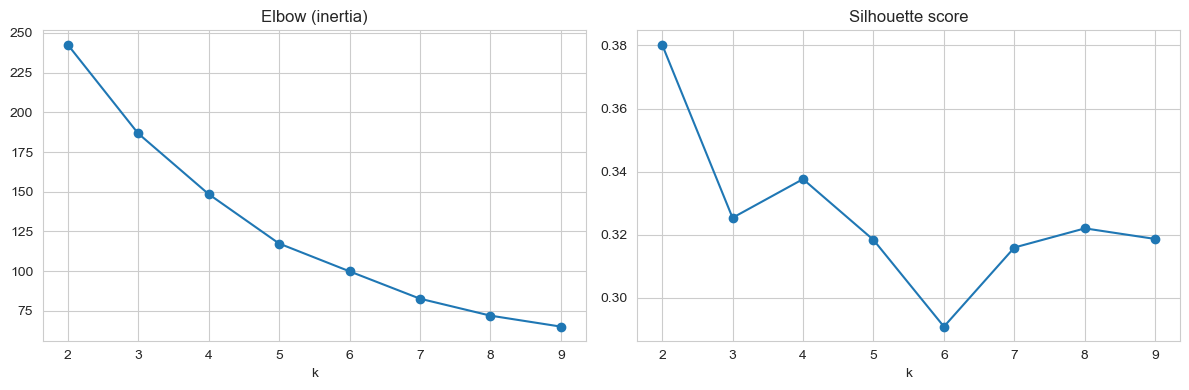

Suggested k (highest silhouette): 2


In [6]:
features_a = vol[["cv", "avg_daily_range_pct", "log_price_mean"]].dropna()
X_a = StandardScaler().fit_transform(features_a)

# elbow + silhouette to help pick k
inertias, sils = [], []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_a)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_a, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, marker="o"); axes[0].set_title("Elbow (inertia)"); axes[0].set_xlabel("k")
axes[1].plot(list(K_range), sils, marker="o"); axes[1].set_title("Silhouette score"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()

print("Suggested k (highest silhouette):", list(K_range)[int(np.argmax(sils))])

In [7]:
K_VOLATILITY = list(K_range)[int(np.argmax(sils))]   # override manually if you prefer a different k

km_a = KMeans(n_clusters=K_VOLATILITY, n_init=10, random_state=42)
features_a = features_a.copy()
features_a["volatility_cluster"] = km_a.fit_predict(X_a)

print(f"k={K_VOLATILITY} | silhouette={silhouette_score(X_a, features_a['volatility_cluster']):.3f}")
features_a.groupby("volatility_cluster")[["cv", "avg_daily_range_pct", "log_price_mean"]].mean()

k=2 | silhouette=0.380


,cv,avg_daily_range_pct,log_price_mean
volatility_cluster,,,
0,0.403770,0.143348,3.983314
1,0.284505,0.081781,5.114469


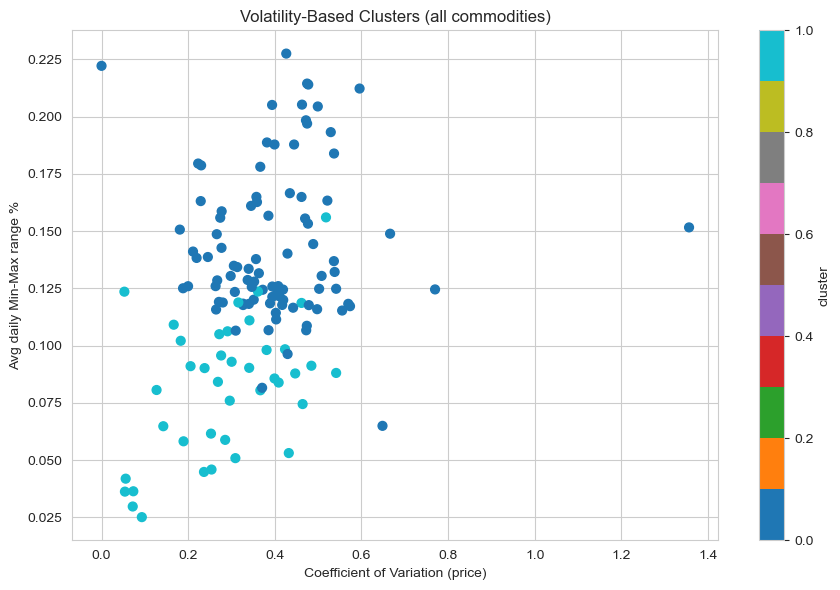

In [8]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(features_a["cv"], features_a["avg_daily_range_pct"],
                 c=features_a["volatility_cluster"], cmap="tab10", s=40)
ax.set_xlabel("Coefficient of Variation (price)"); ax.set_ylabel("Avg daily Min-Max range %")
ax.set_title("Volatility-Based Clusters (all commodities)")
plt.colorbar(sc, label="cluster")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/volatility_clusters.png", dpi=150); plt.show()

## 5. Feature-Based Clustering B — Volatility + Seasonality (Tier 1 only)

Richer clustering for the commodities with enough history to trust a seasonal decomposition.

In [9]:
features_b = vol.loc[vol["tier"] == "Tier1_full_history", ["cv", "avg_daily_range_pct", "log_price_mean"]] \
    .join(seasonality[["seasonal_strength", "trend_strength"]], how="inner")
X_b = StandardScaler().fit_transform(features_b)

sils_b = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_b)
    sils_b.append(silhouette_score(X_b, km.labels_))

K_FULL = list(K_range)[int(np.argmax(sils_b))]
print("Suggested k for full feature set:", K_FULL)

km_b = KMeans(n_clusters=K_FULL, n_init=10, random_state=42)
features_b = features_b.copy()
features_b["full_cluster"] = km_b.fit_predict(X_b)
features_b.groupby("full_cluster")[["cv", "avg_daily_range_pct", "seasonal_strength", "trend_strength"]].mean()

Suggested k for full feature set: 2


,cv,avg_daily_range_pct,seasonal_strength,trend_strength
full_cluster,,,,
0,0.336466,0.090138,0.205130,0.529478
1,0.401997,0.138335,0.389281,0.231359


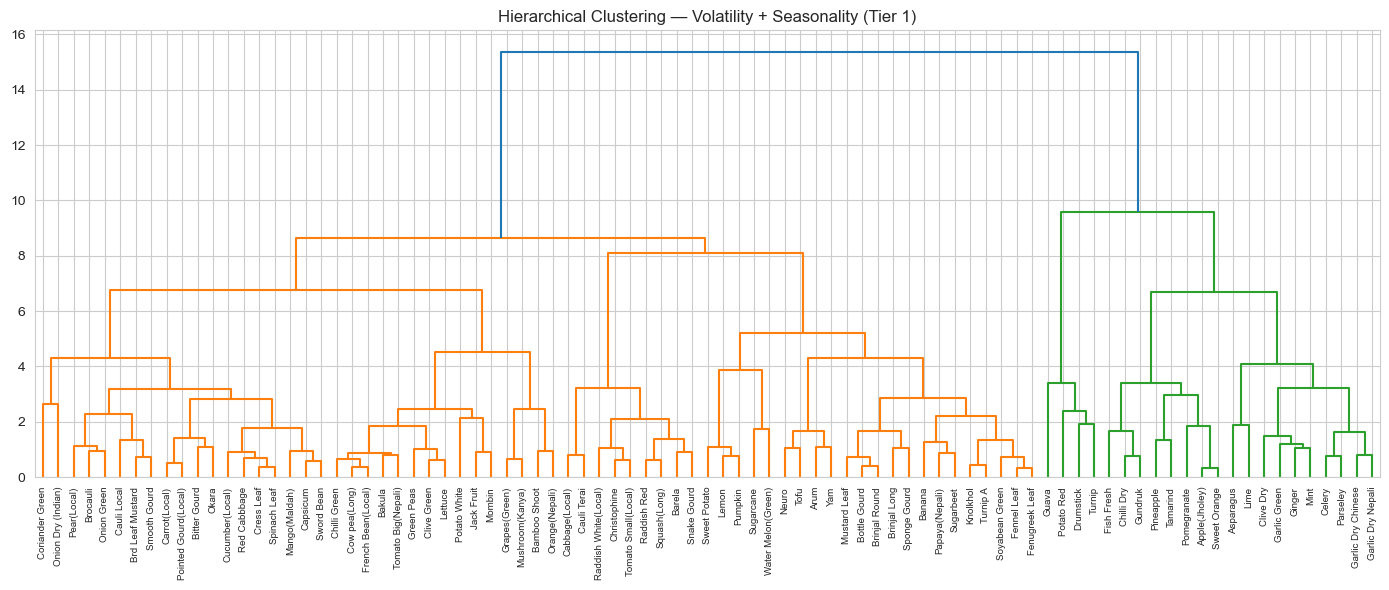

In [10]:
# Hierarchical clustering as a second view -- dendrogram helps you pick a natural cut
Z = linkage(X_b, method="ward")
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, labels=features_b.index.tolist(), leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title("Hierarchical Clustering — Volatility + Seasonality (Tier 1)")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/hierarchical_dendrogram.png", dpi=150); plt.show()

In [11]:
features_b["hier_cluster"] = fcluster(Z, t=K_FULL, criterion="maxclust")

print("Example commodities per full_cluster (KMeans):")
for c in sorted(features_b["full_cluster"].unique()):
    names = features_b[features_b["full_cluster"] == c].index.tolist()
    print(f"\nCluster {c} (n={len(names)}):", names[:12], "..." if len(names) > 12 else "")

Example commodities per full_cluster (KMeans):

Cluster 0 (n=23): ['Apple(Jholey)', 'Asparagus', 'Bamboo Shoot', 'Celery', 'Chilli Dry', 'Clive Dry', 'Drumstick', 'Fish Fresh', 'Garlic Dry Chinese', 'Garlic Dry Nepali', 'Ginger', 'Grapes(Green)'] ...

Cluster 1 (n=64): ['Arum', 'Bakula', 'Banana', 'Barela', 'Bitter Gourd', 'Bottle Gourd', 'Brd Leaf Mustard', 'Brinjal Long', 'Brinjal Round', 'Brocauli', 'Cabbage(Local)', 'Capsicum'] ...


## 6. Shape-Based Clustering — DTW on Seasonal Profiles

Instead of clustering on summary statistics, this clusters commodities by the **actual shape** of their month-of-year price curve — captures "these two peak in the same months and dip in the same months" even when their volatility or price level differs.

Steps: build a 12-point average-price-by-calendar-month profile per commodity, normalize (z-score) so shape matters more than scale, then cluster using DTW distance.

In [12]:
def monthly_profile(df, commodity):
    g = df[df[COMMODITY_COL] == commodity]
    monthly = g.groupby("Month")["Average"].mean()
    if monthly.isna().sum() > 0 or len(monthly) < MIN_MONTHS_FOR_PROFILE:
        return None
    monthly = monthly.reindex(range(1, 13))
    if monthly.isna().any():
        monthly = monthly.interpolate(limit_direction="both")
    z = (monthly - monthly.mean()) / monthly.std() if monthly.std() > 0 else monthly * 0
    return z.values

profiles = {}
for c in df[COMMODITY_COL].unique():
    p = monthly_profile(df, c)
    if p is not None:
        profiles[c] = p

profile_names = list(profiles.keys())
profile_matrix = np.array([profiles[c] for c in profile_names])
print(f"Built seasonal profiles for {len(profile_names)} / {df[COMMODITY_COL].nunique()} commodities")

Built seasonal profiles for 121 / 132 commodities


In [13]:
def dtw_distance(a, b):
    """Classic DTW distance, O(n*m). Cheap here since n=m=12."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(a[i - 1] - b[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D[n, m]

n = len(profile_names)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1, n):
        d = dtw_distance(profile_matrix[i], profile_matrix[j])
        dist_matrix[i, j] = dist_matrix[j, i] = d

print("DTW distance matrix shape:", dist_matrix.shape)

DTW distance matrix shape: (121, 121)


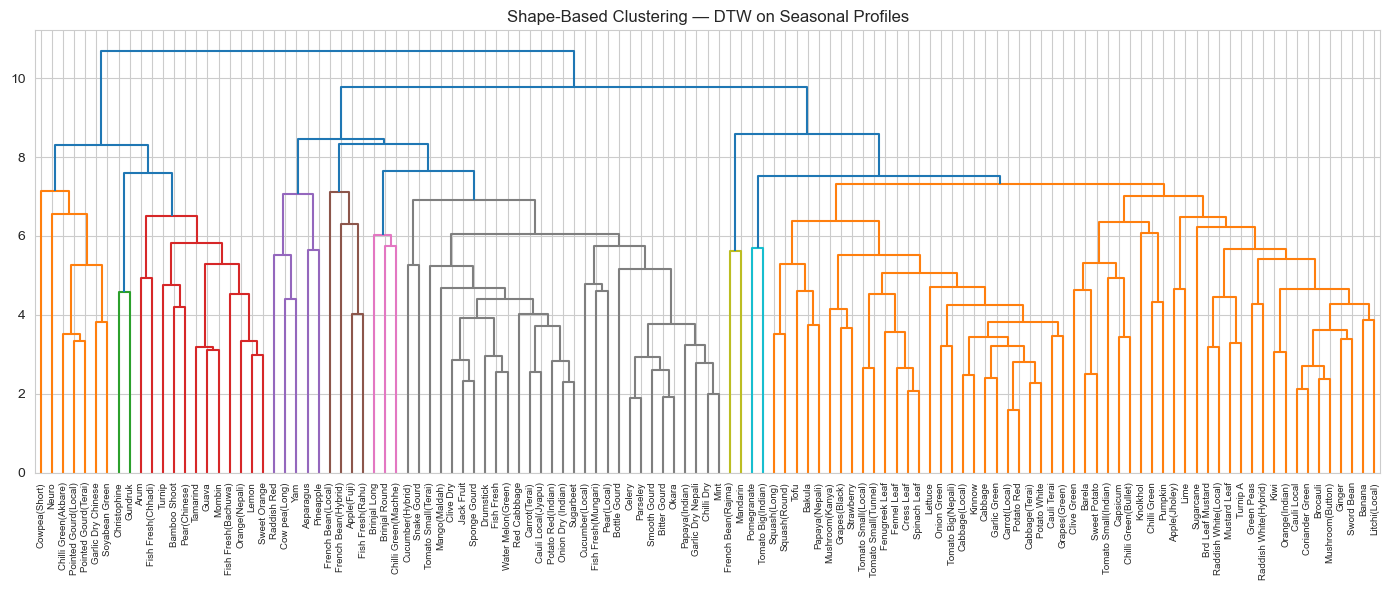

In [14]:
condensed = squareform(dist_matrix, checks=False)
Z_dtw = linkage(condensed, method="average")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z_dtw, labels=profile_names, leaf_rotation=90, leaf_font_size=7, ax=ax)
ax.set_title("Shape-Based Clustering — DTW on Seasonal Profiles")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/dtw_dendrogram.png", dpi=150); plt.show()

In [15]:
K_SHAPE = 6   # adjust based on the dendrogram above
shape_clusters = pd.Series(fcluster(Z_dtw, t=K_SHAPE, criterion="maxclust"),
                            index=profile_names, name="shape_cluster")

print("Example commodities per shape_cluster:")
for c in sorted(shape_clusters.unique()):
    names = shape_clusters[shape_clusters == c].index.tolist()
    print(f"\nCluster {c} (n={len(names)}):", names[:12], "..." if len(names) > 12 else "")

Example commodities per shape_cluster:

Cluster 1 (n=21): ['Arum', 'Bamboo Shoot', 'Chilli Green(Akbare)', 'Christophine', 'Cowpea(Short)', 'Fish Fresh(Bachuwa)', 'Fish Fresh(Chhadi)', 'Garlic Dry Chinese', 'Guava', 'Gundruk', 'Lemon', 'Mombin'] ...

Cluster 2 (n=5): ['Asparagus', 'Cow pea(Long)', 'Pineapple', 'Raddish Red', 'Yam'] 

Cluster 3 (n=4): ['Apple(Fuji)', 'Fish Fresh(Rahu)', 'French Bean(Hybrid)', 'French Bean(Local)'] 

Cluster 4 (n=32): ['Bitter Gourd', 'Bottle Gourd', 'Brinjal Long', 'Brinjal Round', 'Carrot(Terai)', 'Cauli Local(Jyapu)', 'Celery', 'Chilli Dry', 'Chilli Green(Machhe)', 'Clive Dry', 'Cucumber(Hybrid)', 'Cucumber(Local)'] ...

Cluster 5 (n=2): ['French Bean(Rajma)', 'Mandarin'] 

Cluster 6 (n=57): ['Apple(Jholey)', 'Bakula', 'Banana', 'Barela', 'Brd Leaf Mustard', 'Brocauli', 'Cabbage', 'Cabbage(Local)', 'Cabbage(Terai)', 'Capsicum', 'Carrot(Local)', 'Cauli Local'] ...


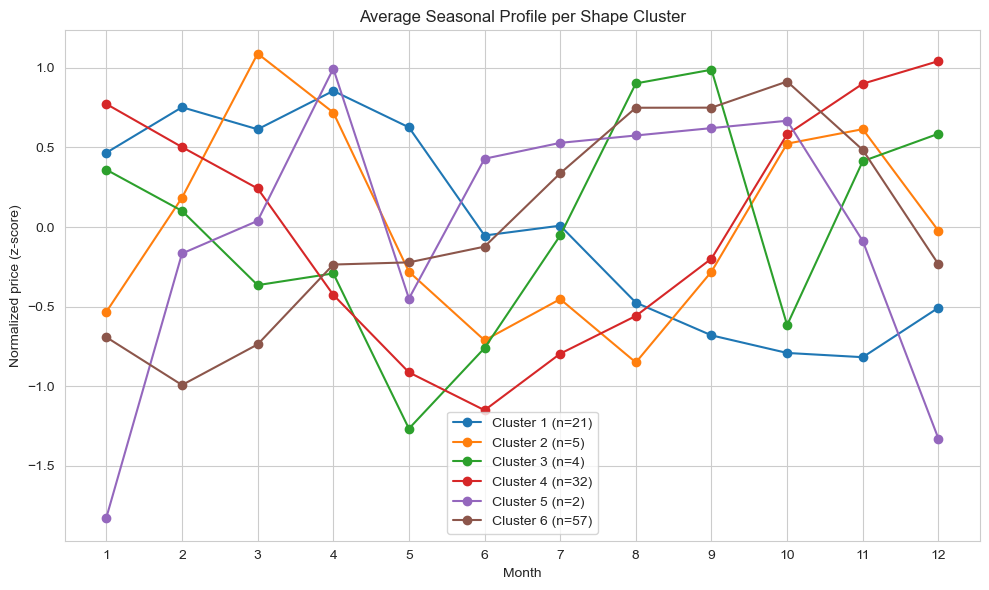

In [16]:
# visualize average seasonal profile per shape cluster
fig, ax = plt.subplots(figsize=(10, 6))
for c in sorted(shape_clusters.unique()):
    members = shape_clusters[shape_clusters == c].index
    avg_profile = np.mean([profiles[m] for m in members], axis=0)
    ax.plot(range(1, 13), avg_profile, marker="o", label=f"Cluster {c} (n={len(members)})")
ax.set_xlabel("Month"); ax.set_ylabel("Normalized price (z-score)")
ax.set_xticks(range(1, 13))
ax.set_title("Average Seasonal Profile per Shape Cluster")
ax.legend()
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/shape_cluster_profiles.png", dpi=150); plt.show()

## 7. Combine Everything Into One Output Table

In [17]:
final = coverage.set_index("Commodity")[["tier", "n_obs", "span_days"]].copy()
final = final.join(vol[["cv", "avg_daily_range_pct", "price_mean"]])
final = final.join(features_a["volatility_cluster"])
final = final.join(features_b[["full_cluster", "hier_cluster"]])
final = final.join(seasonality[["seasonal_strength", "trend_strength", "peak_month"]])
final = final.join(shape_clusters)

final.to_csv(f"{OUTPUT_DIR}/commodity_clusters.csv")
print(f"Saved -> {OUTPUT_DIR}/commodity_clusters.csv")
final.head(15)

Saved -> d:\ShaunakKathavate Github\vegetable_and_fruits_time_series_and_clustering\reports\from notebooks\clustering_outputs/commodity_clusters.csv


,tier,n_obs,span_days,cv,avg_daily_range_pct,price_mean,volatility_cluster,full_cluster,hier_cluster,seasonal_strength,trend_strength,peak_month,shape_cluster
Commodity,,,,,,,,,,,,,
Apple(Fuji),Tier2_sparse,395,714,0.142566,0.064812,280.025316,1,NaN,NaN,NaN,NaN,NaN,3.0
Apple(Jholey),Tier1_full_history,2683,2888,0.300289,0.092966,122.283824,1,0.0,2.0,0.113,0.479,10.0,6.0
Arum,Tier1_full_history,2020,2880,0.211184,0.141109,42.602228,0,1.0,1.0,0.082,0.429,5.0,1.0
Asparagus,Tier1_full_history,1055,2889,0.461566,0.118661,321.646919,1,0.0,2.0,0.139,0.259,3.0,2.0
Bakula,Tier1_full_history,1131,2768,0.351259,0.120085,67.066313,0,1.0,1.0,0.122,0.252,10.0,6.0
Bamboo Shoot,Tier1_full_history,2744,2889,0.271748,0.105008,101.347485,1,0.0,1.0,0.000,0.205,4.0,1.0
Banana,Tier1_full_history,2744,2889,0.263282,0.125999,78.394133,0,1.0,1.0,0.498,0.407,5.0,6.0
Barela,Tier1_full_history,1390,2832,0.385180,0.156755,44.121942,0,1.0,1.0,0.277,0.116,9.0,6.0
Bauhania flower,Tier1_full_history,286,2616,0.569476,0.118274,119.169580,0,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Name the Clusters

Cluster numbers (0, 1, 2...) aren't meaningful on their own. This section derives a **descriptive name for each cluster automatically** from its own statistics, so the naming is grounded in your actual data rather than guessed:

- **Volatility clusters** → named by where their mean CV ranks relative to the other clusters (bottom third / middle third / top third → Stable / Moderate / High Volatility)
- **Volatility+Seasonality clusters** → named by whether they sit above/below the *median across clusters* on both CV and seasonal strength (e.g. "Stable, Strongly Seasonal")
- **Shape clusters** → named by the calendar month their averaged seasonal profile peaks in, mapped to a season label

All three naming schemes are threshold-free in the sense that they rank clusters relative to each other, not against a fixed number — so they still make sense however many clusters `k` ends up being. The **season mapping below assumes a Nepal/South-Asia calendar (monsoon June–Sep)** — adjust `SEASON_MAP` if your data is from a different region.

In [18]:
# --- Name volatility clusters (relative rank on mean CV) ---
vol_stats = features_a.groupby("volatility_cluster")[["cv", "avg_daily_range_pct", "log_price_mean"]].mean()
vol_stats = vol_stats.sort_values("cv").reset_index()
vol_stats["rank"] = range(len(vol_stats))

def volatility_label(rank, total):
    frac = rank / max(total - 1, 1)
    if frac < 0.34:
        return "Stable / Low Volatility"
    elif frac < 0.67:
        return "Moderate Volatility"
    return "High Volatility"

vol_stats["cluster_name"] = [
    f'{volatility_label(r, len(vol_stats))} (Cluster {c})'
    for r, c in zip(vol_stats["rank"], vol_stats["volatility_cluster"])
]

volatility_name_map = dict(zip(vol_stats["volatility_cluster"], vol_stats["cluster_name"]))
features_a["volatility_cluster_name"] = features_a["volatility_cluster"].map(volatility_name_map)

print("Volatility cluster names:")
vol_stats[["volatility_cluster", "cluster_name", "cv", "avg_daily_range_pct"]]

Volatility cluster names:


,volatility_cluster,cluster_name,cv,avg_daily_range_pct
0,1,Stable / Low Volatility (Cluster 1),0.284505,0.081781
1,0,High Volatility (Cluster 0),0.403770,0.143348


In [19]:
# --- Commodities per volatility cluster ---
for name, grp in features_a.groupby("volatility_cluster_name"):
    print(f"\n{name}  (n={len(grp)})")
    print(", ".join(sorted(grp.index.tolist())))


High Volatility (Cluster 0)  (n=92)
Arum, Bakula, Banana, Barela, Bauhania flower, Bitter Gourd, Bottle Gourd, Brd Leaf Mustard, Brinjal Long, Brinjal Round, Brocauli, Cabbage, Cabbage(Local), Cabbage(Terai), Capsicum, Carrot(Local), Carrot(Terai), Cauli Local, Cauli Local(Jyapu), Cauli Terai, Chilli Green, Chilli Green(Bullet), Chilli Green(Machhe), Christophine, Clive Green, Coriander Green, Cow pea(Long), Cowpea(Short), Cress Leaf, Cucumber(Hybrid), Cucumber(Local), Fennel Leaf, Fenugreek Leaf, French Bean(Hybrid), French Bean(Local), Garlic Green, Ginger, Green Peas, Guava, Jack Fruit, Kinnow, Knolkhol, Lemon, Lettuce, Maize, Mandarin, Mango(Chousa), Mango(Maldah), Mombin, Musk Melon, Mustard Leaf, Neuro, Okara, Onion Dry (Indian), Onion Green, Orange(Nepali), Papaya(Nepali), Pear(Local), Pointed Gourd(Local), Pointed Gourd(Terai), Potato Red, Potato Red(Indian), Potato White, Pumpkin, Raddish Red, Raddish White(Hybrid), Raddish White(Local), Red Cabbbage, Smooth Gourd, Snake Gour

In [20]:
# --- Name volatility+seasonality clusters (above/below median on each axis) ---
full_stats = features_b.groupby("full_cluster")[["cv", "seasonal_strength", "trend_strength"]].mean()
cv_median = full_stats["cv"].median()
season_median = full_stats["seasonal_strength"].median()

def full_label(row):
    vol_tag = "High-Volatility" if row["cv"] >= cv_median else "Stable"
    season_tag = "Strongly Seasonal" if row["seasonal_strength"] >= season_median else "Weakly Seasonal"
    return f"{vol_tag}, {season_tag}"

full_stats = full_stats.reset_index()
full_stats["cluster_name"] = [
    f'{full_label(row)} (Cluster {row["full_cluster"]})' for _, row in full_stats.iterrows()
]

full_name_map = dict(zip(full_stats["full_cluster"], full_stats["cluster_name"]))
features_b["full_cluster_name"] = features_b["full_cluster"].map(full_name_map)

print("Volatility+Seasonality cluster names:")
full_stats[["full_cluster", "cluster_name", "cv", "seasonal_strength", "trend_strength"]]

Volatility+Seasonality cluster names:


,full_cluster,cluster_name,cv,seasonal_strength,trend_strength
0,0,"Stable, Weakly Seasonal (Cluster 0.0)",0.336466,0.205130,0.529478
1,1,"High-Volatility, Strongly Seasonal (Cluster 1.0)",0.401997,0.389281,0.231359


In [21]:
# --- Commodities per volatility+seasonality cluster ---
for name, grp in features_b.groupby("full_cluster_name"):
    print(f"\n{name}  (n={len(grp)})")
    print(", ".join(sorted(grp.index.tolist())))


High-Volatility, Strongly Seasonal (Cluster 1.0)  (n=64)
Arum, Bakula, Banana, Barela, Bitter Gourd, Bottle Gourd, Brd Leaf Mustard, Brinjal Long, Brinjal Round, Brocauli, Cabbage(Local), Capsicum, Carrot(Local), Cauli Local, Cauli Terai, Chilli Green, Christophine, Clive Green, Coriander Green, Cow pea(Long), Cress Leaf, Cucumber(Local), Fennel Leaf, Fenugreek Leaf, French Bean(Local), Garlic Green, Green Peas, Guava, Jack Fruit, Knolkhol, Lemon, Lettuce, Mango(Maldah), Mombin, Mustard Leaf, Okara, Onion Dry (Indian), Onion Green, Orange(Nepali), Papaya(Nepali), Pear(Local), Pointed Gourd(Local), Potato Red, Potato White, Pumpkin, Raddish Red, Raddish White(Local), Red Cabbbage, Smooth Gourd, Snake Gourd, Soyabean Green, Spinach Leaf, Sponge Gourd, Squash(Long), Sugarbeet, Sugarcane, Sweet Potato, Sword Bean, Tomato Big(Nepali), Tomato Small(Local), Turnip, Turnip A, Water Melon(Green), Yam

Stable, Weakly Seasonal (Cluster 0.0)  (n=23)
Apple(Jholey), Asparagus, Bamboo Shoot, Celery,

In [22]:
# --- Name shape clusters by peak season (adjust SEASON_MAP for your region) ---
SEASON_MAP = {
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Monsoon", 7: "Monsoon", 8: "Monsoon", 9: "Monsoon",
    10: "Autumn", 11: "Autumn",
}

shape_name_map = {}
for c in sorted(shape_clusters.unique()):
    members = shape_clusters[shape_clusters == c].index
    avg_profile = np.mean([profiles[m] for m in members], axis=0)
    peak_month = int(np.argmax(avg_profile)) + 1
    season = SEASON_MAP[peak_month]
    shape_name_map[c] = f"{season} Peak (Month {peak_month}) (Cluster {c})"

shape_cluster_names = shape_clusters.map(shape_name_map).rename("shape_cluster_name")

print("Shape cluster names:")
for c, name in shape_name_map.items():
    print(f"  Cluster {c}: {name}")

Shape cluster names:
  Cluster 1: Spring Peak (Month 4) (Cluster 1)
  Cluster 2: Spring Peak (Month 3) (Cluster 2)
  Cluster 3: Monsoon Peak (Month 9) (Cluster 3)
  Cluster 4: Winter Peak (Month 12) (Cluster 4)
  Cluster 5: Spring Peak (Month 4) (Cluster 5)
  Cluster 6: Autumn Peak (Month 10) (Cluster 6)


In [23]:
# --- Commodities per shape cluster ---
for name, grp in shape_cluster_names.groupby(shape_cluster_names):
    members = grp.index.tolist()
    print(f"\n{name}  (n={len(members)})")
    print(", ".join(sorted(members)))


Autumn Peak (Month 10) (Cluster 6)  (n=57)
Apple(Jholey), Bakula, Banana, Barela, Brd Leaf Mustard, Brocauli, Cabbage, Cabbage(Local), Cabbage(Terai), Capsicum, Carrot(Local), Cauli Local, Cauli Terai, Chilli Green, Chilli Green(Bullet), Clive Green, Coriander Green, Cress Leaf, Fennel Leaf, Fenugreek Leaf, Garlic Green, Ginger, Grapes(Black), Grapes(Green), Green Peas, Kinnow, Kiwi, Knolkhol, Lettuce, Lime, Litchi(Local), Mushroom(Button), Mushroom(Kanya), Mustard Leaf, Onion Green, Orange(Indian), Papaya(Nepali), Pomegranate, Potato Red, Potato White, Pumpkin, Raddish White(Hybrid), Raddish White(Local), Spinach Leaf, Squash(Long), Squash(Round), Strawberry, Sugarcane, Sweet Potato, Sword Bean, Tofu, Tomato Big(Indian), Tomato Big(Nepali), Tomato Small(Indian), Tomato Small(Local), Tomato Small(Tunnel), Turnip A

Monsoon Peak (Month 9) (Cluster 3)  (n=4)
Apple(Fuji), Fish Fresh(Rahu), French Bean(Hybrid), French Bean(Local)

Spring Peak (Month 3) (Cluster 2)  (n=5)
Asparagus, Cow pe

In [24]:
# --- Save a single named lookup table: Commodity -> all three cluster names ---
named = pd.DataFrame(index=coverage.set_index("Commodity").index)
named["volatility_cluster_name"] = features_a["volatility_cluster_name"]
named["full_cluster_name"] = features_b["full_cluster_name"]
named["shape_cluster_name"] = shape_cluster_names

named.to_csv(f"{OUTPUT_DIR}/commodity_clusters_named.csv")
print(f"Saved -> {OUTPUT_DIR}/commodity_clusters_named.csv")
named

Saved -> d:\ShaunakKathavate Github\vegetable_and_fruits_time_series_and_clustering\reports\from notebooks\clustering_outputs/commodity_clusters_named.csv


,volatility_cluster_name,full_cluster_name,shape_cluster_name
Commodity,,,
Apple(Fuji),Stable / Low Volatility (Cluster 1),NaN,Monsoon Peak (Month 9) (Cluster 3)
Apple(Jholey),Stable / Low Volatility (Cluster 1),"Stable, Weakly Seasonal (Cluster 0.0)",Autumn Peak (Month 10) (Cluster 6)
Arum,High Volatility (Cluster 0),"High-Volatility, Strongly Seasonal (Cluster 1.0)",Spring Peak (Month 4) (Cluster 1)
Asparagus,Stable / Low Volatility (Cluster 1),"Stable, Weakly Seasonal (Cluster 0.0)",Spring Peak (Month 3) (Cluster 2)
Bakula,High Volatility (Cluster 0),"High-Volatility, Strongly Seasonal (Cluster 1.0)",Autumn Peak (Month 10) (Cluster 6)
...,...,...,...
Turnip,High Volatility (Cluster 0),"High-Volatility, Strongly Seasonal (Cluster 1.0)",Spring Peak (Month 4) (Cluster 1)
Turnip A,High Volatility (Cluster 0),"High-Volatility, Strongly Seasonal (Cluster 1.0)",Autumn Peak (Month 10) (Cluster 6)
Water Melon(Dotted),High Volatility (Cluster 0),NaN,NaN


## 9. Summary & Next Steps

Outputs in `./clustering_outputs/`:
- `volatility_features.csv` — CV, price range %, tier, per commodity (all commodities)
- `seasonality_features.csv` — STL seasonal/trend strength, peak month (Tier 1 only)
- `commodity_clusters.csv` — combined table: `volatility_cluster` (all commodities), `full_cluster`/`hier_cluster` (Tier 1, volatility+seasonality), `shape_cluster` (DTW on seasonal curve shape)
- Dendrograms, elbow/silhouette plots, cluster profile charts (PNG)

**How to read the three cluster columns together:**
- `volatility_cluster` tells you risk/stability grouping — usable for every commodity, including new/sparse ones
- `full_cluster` / `hier_cluster` tells you the richer "trades like" grouping for well-established commodities
- `shape_cluster` tells you which commodities peak/dip in the same months, regardless of how volatile or expensive they are — most directly useful for "when should I plant/sell/buy X"

**Next step:** forecasting. `commodity_clusters.csv`'s cluster labels can be fed into a global forecasting model (e.g., LightGBM with cluster ID as a categorical feature) so commodities with sparse individual history borrow statistical strength from others in the same behavioral cluster.